<a href="https://colab.research.google.com/github/fajareka1/PCVK_Ganjil_2026_v2/blob/main/Modul2_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup Awal — Import Library

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io as skio
from google.colab.patches import cv2_imshow

### 0.1 (Opsional) Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 0.2 Upload Gambar

In [ ]:
from google.colab import files

uploaded = files.upload()
print("File terupload:", list(uploaded.keys()))

Saving ktm.jpeg to ktm (1).jpeg
Saving potrait.jpg to potrait (1).jpg
Saving landscape.jpg to landscape (1).jpg
Saving aktivitas.jpg to aktivitas (1).jpg
File terupload: ['ktm (1).jpeg', 'potrait (1).jpg', 'landscape (1).jpg', 'aktivitas (1).jpg']


### 0.3 Menentukan nama file yang dipakai

In [ ]:
import os

FILE_KTM = "ktm.jpeg"
FILE_AKTIVITAS = "aktivitas.jpg"
FILE_POTRET = "potrait.jpg"
FILE_LANSKAP = "landscape.jpg"

FILE_UTAMA = FILE_KTM or FILE_AKTIVITAS or FILE_POTRET or FILE_LANSKAP

## 1. PRAKTIKUM D1 — Pengenalan Python: Pengolahan Citra Dasar & Channel Warna OpenCV

### 1.1 Membaca dan Menampilkan Gambar

Ukuran citra (h, w, c): (912, 1500, 3)
Tampil dengan cv2_imshow() -> asumsi BGR:


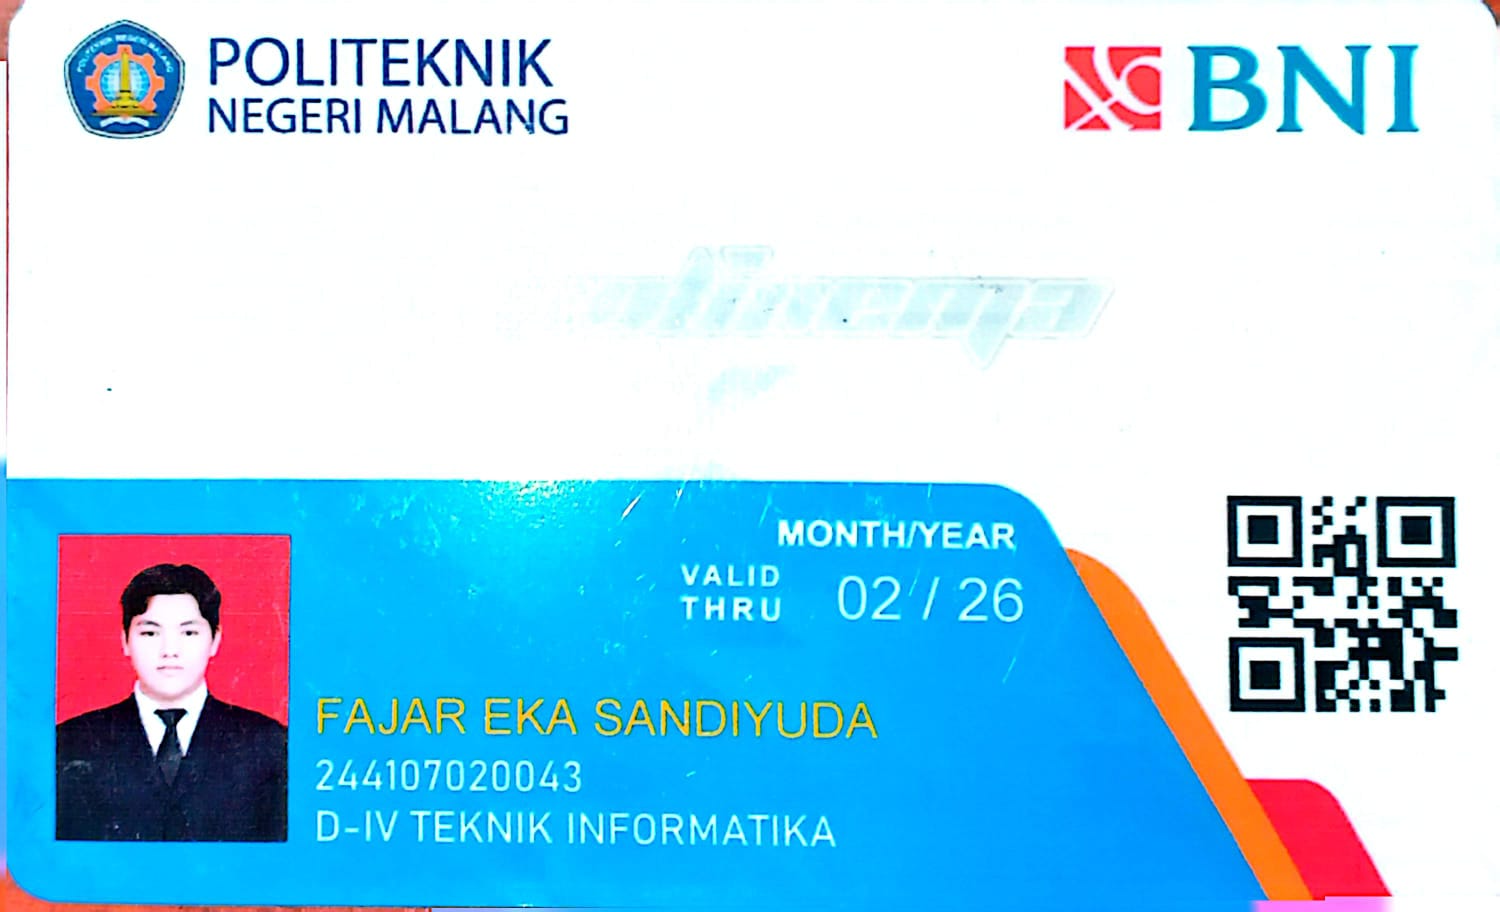

In [ ]:
if FILE_UTAMA:
    img = cv.imread(FILE_UTAMA)
    print("Ukuran citra (h, w, c):", img.shape)

    print("Tampil dengan cv2_imshow() -> asumsi BGR:")
    cv2_imshow(img)
else:
    print("Lewati: belum ada citra utama yang diupload.")

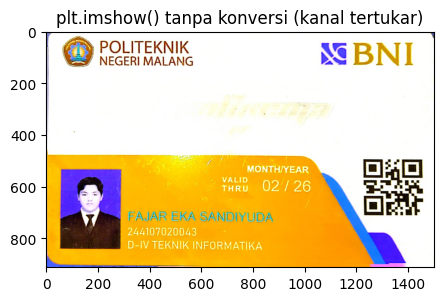

In [ ]:
if FILE_UTAMA:
    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.title("plt.imshow() tanpa konversi (kanal tertukar)")
    plt.show()
else:
    print("Lewati: belum ada citra utama yang diupload.")

### 1.2 Konversi BGR → RGB

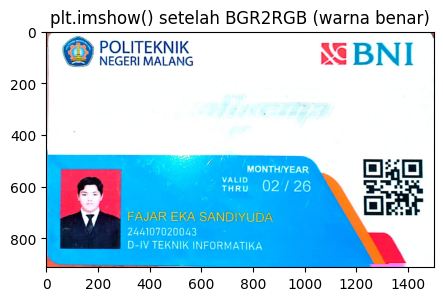

Apakah hasil cvtColor sama dengan hasil slicing? True


In [ ]:
if FILE_UTAMA:
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    # alternatif tanpa cvtColor:
    img_rgb_slice = img[:, :, ::-1]

    plt.figure(figsize=(5, 4))
    plt.imshow(img_rgb)
    plt.title("plt.imshow() setelah BGR2RGB (warna benar)")
    plt.show()

    print("Apakah hasil cvtColor sama dengan hasil slicing?", np.array_equal(img_rgb, img_rgb_slice))
else:
    print("Lewati: belum ada citra utama yang diupload.")

### 1.3 Menampilkan Citra Grayscale & Colormap

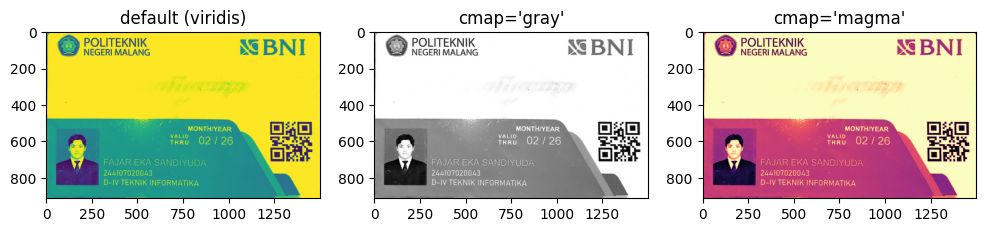

In [ ]:
if FILE_UTAMA:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(gray)              # colormap default 'viridis'
    axes[0].set_title("default (viridis)")
    axes[1].imshow(gray, cmap='gray') # tampil hitam-putih sebenarnya
    axes[1].set_title("cmap='gray'")
    axes[2].imshow(gray, cmap='magma')# pseudocolor
    axes[2].set_title("cmap='magma'")
    plt.show()
else:
    print("Lewati: belum ada citra utama yang diupload.")

### 1.4 Resizing (Mengubah Ukuran Citra)

Ukuran awal (h, w): (912, 1500)
Ukuran setelah resize (h, w): (456, 750)


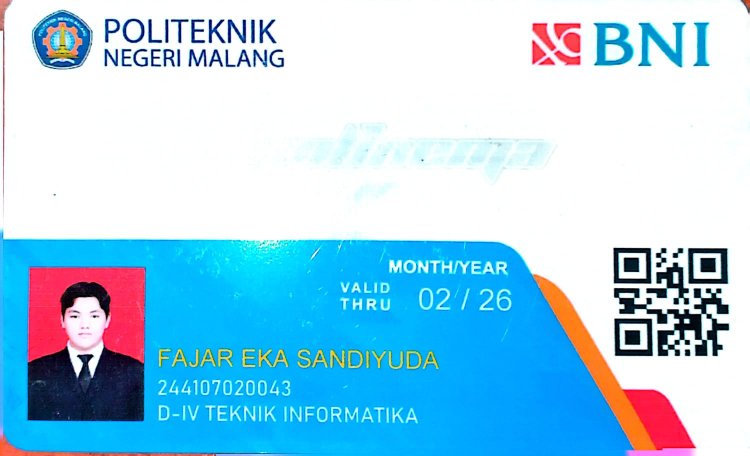

In [ ]:
if FILE_UTAMA:
    h, w = img.shape[:2]
    ukuran_baru = (w // 2, h // 2)   # cv.resize menerima (lebar, tinggi)
    img_resized = cv.resize(img, ukuran_baru)

    print("Ukuran awal (h, w):", (h, w))
    print("Ukuran setelah resize (h, w):", img_resized.shape[:2])

    cv2_imshow(img_resized)
else:
    print("Lewati: belum ada citra utama yang diupload.")

### 1.5 Flipping

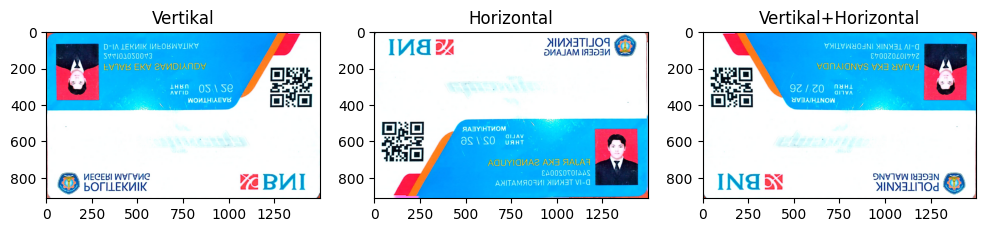

In [ ]:
if FILE_UTAMA:
    flip_v = cv.flip(img, 0)   # vertikal
    flip_h = cv.flip(img, 1)   # horizontal
    flip_vh = cv.flip(img, -1) # keduanya

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, im, judul in zip(axes, [flip_v, flip_h, flip_vh], ["Vertikal", "Horizontal", "Vertikal+Horizontal"]):
        ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
        ax.set_title(judul)
    plt.show()
else:
    print("Lewati: belum ada citra utama yang diupload.")

### 1.6 Membuat Kanvas & Menggambar Bentuk Geometri (int16)
Diawali dengan pembuatan black image (kanvas hitam) dengan tipe data int16.

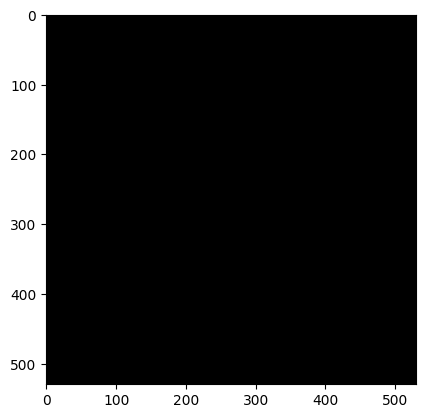

In [ ]:
black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)
plt.imshow(black_img)

Kemudian menambahkan bentuk persegi panjang (rectangle) sesuai koordinat pt1 dan pt2:

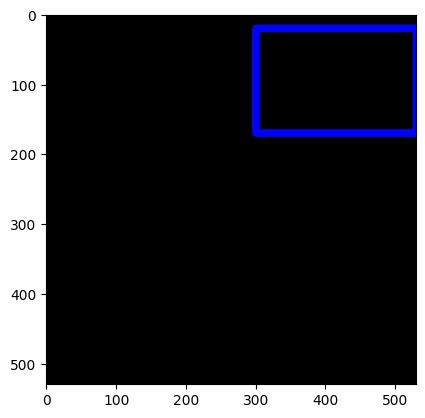

In [ ]:
cv.rectangle(black_img, pt1=(300, 20), pt2=(530, 170), color=(0, 0, 255), thickness=10)
plt.imshow(black_img)

Selanjutnya ditambah menambahkan bentuk persegi (square) sesuai koordinat pt1 dan pt2:

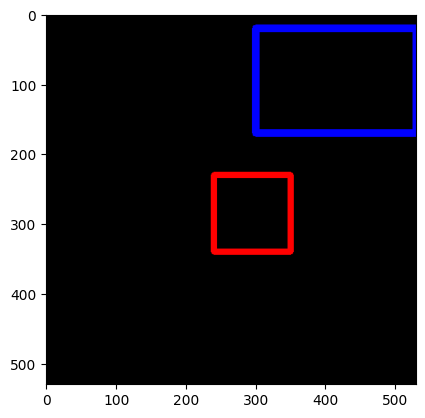

In [ ]:
cv.rectangle(black_img, pt1=(240, 230), pt2=(350, 340), color=(255, 0, 0), thickness=8)
plt.imshow(black_img)

Tahap selanjutnya ditambah menambahkan bentuk lingkaran (circle) sesuai radius yang ditentukan:

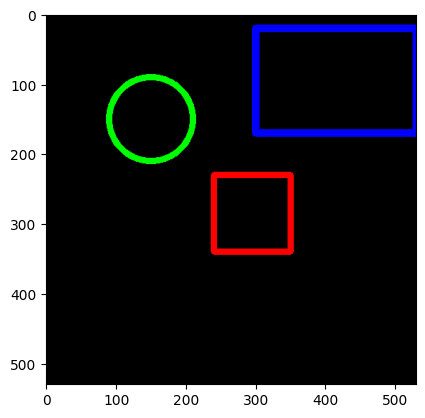

In [ ]:
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8)
plt.imshow(black_img)

Kemudian dilakukan penambahan lingkaran berwarna (solid) dan garis sesuai koordinat pt1 dan pt2 sebagai berikut:

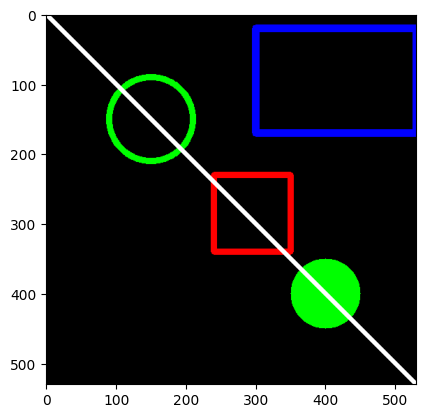

In [ ]:
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)
cv.line(black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)

Penambahan text dengan font yang telah tertulis dengan ukuran yang sudah ditentukan:

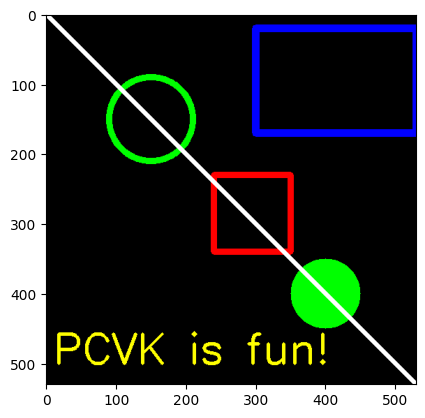

In [ ]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10, 500), fontFace=font, fontScale=2,
           color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

### 1.7 Kanvas int32 & Polyline dari Array NumPy
Pembuatan black image kembali dilakukan dengan tipe data int32.

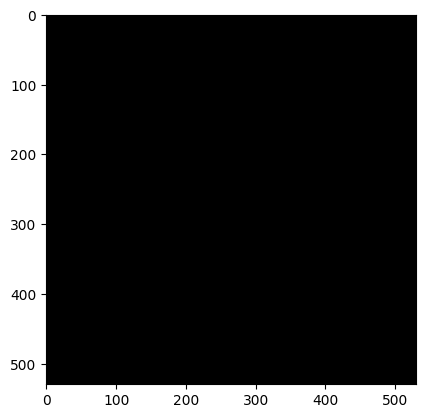

In [ ]:
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)
plt.imshow(black_img2)

Berikut adalah kode program untuk inisialisasi NumPy array dengan tipe data int32:

In [ ]:
pts = np.array([[250, 250], [150, 350], [250, 450], [450, 350]], dtype=np.int32)
pts

array([[250, 250],
       [150, 350],
       [250, 450],
       [450, 350]], dtype=int32)

Array tersebut kemudian di-reshape sebagai berikut:

In [ ]:
pts = pts.reshape((-1, 1, 2))
pts.shape

(4, 1, 2)

Penambahan polyline pada black image kedua yang telah dibuat:

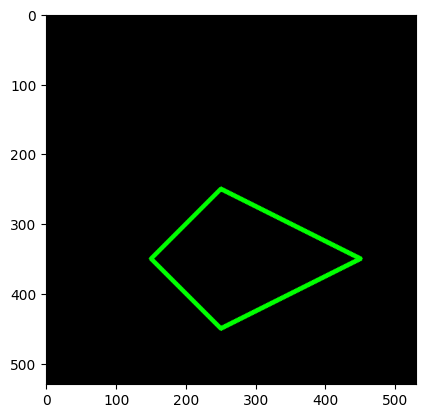

In [ ]:
cv.polylines(black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5, lineType=cv.LINE_AA)
plt.imshow(black_img2)

## 2. PERTANYAAN PRAKTIKUM
Jawab tiap pertanyaan pada sel Markdown, dan buktikan dengan keluaran program pada sel kode di bawahnya.

### Pertanyaan 1
Tampilkan satu citra bebas menggunakan `cv2_imshow()` dan `plt.imshow()` tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

**Jawaban:**
`cv2_imshow()` menampilkan array persis seperti urutan kanalnya (BGR, sesuai cara `cv.imread()` menyimpan data), sedangkan `plt.imshow()` selalu mengasumsikan array masukannya berurutan RGB. Karena array yang sama diberikan ke kedua fungsi tanpa konversi, kanal merah dan biru pada hasil `plt.imshow()` tertukar, sehingga warna yang tampil berbeda meskipun nilai array-nya identik.

cv2_imshow (BGR apa adanya):


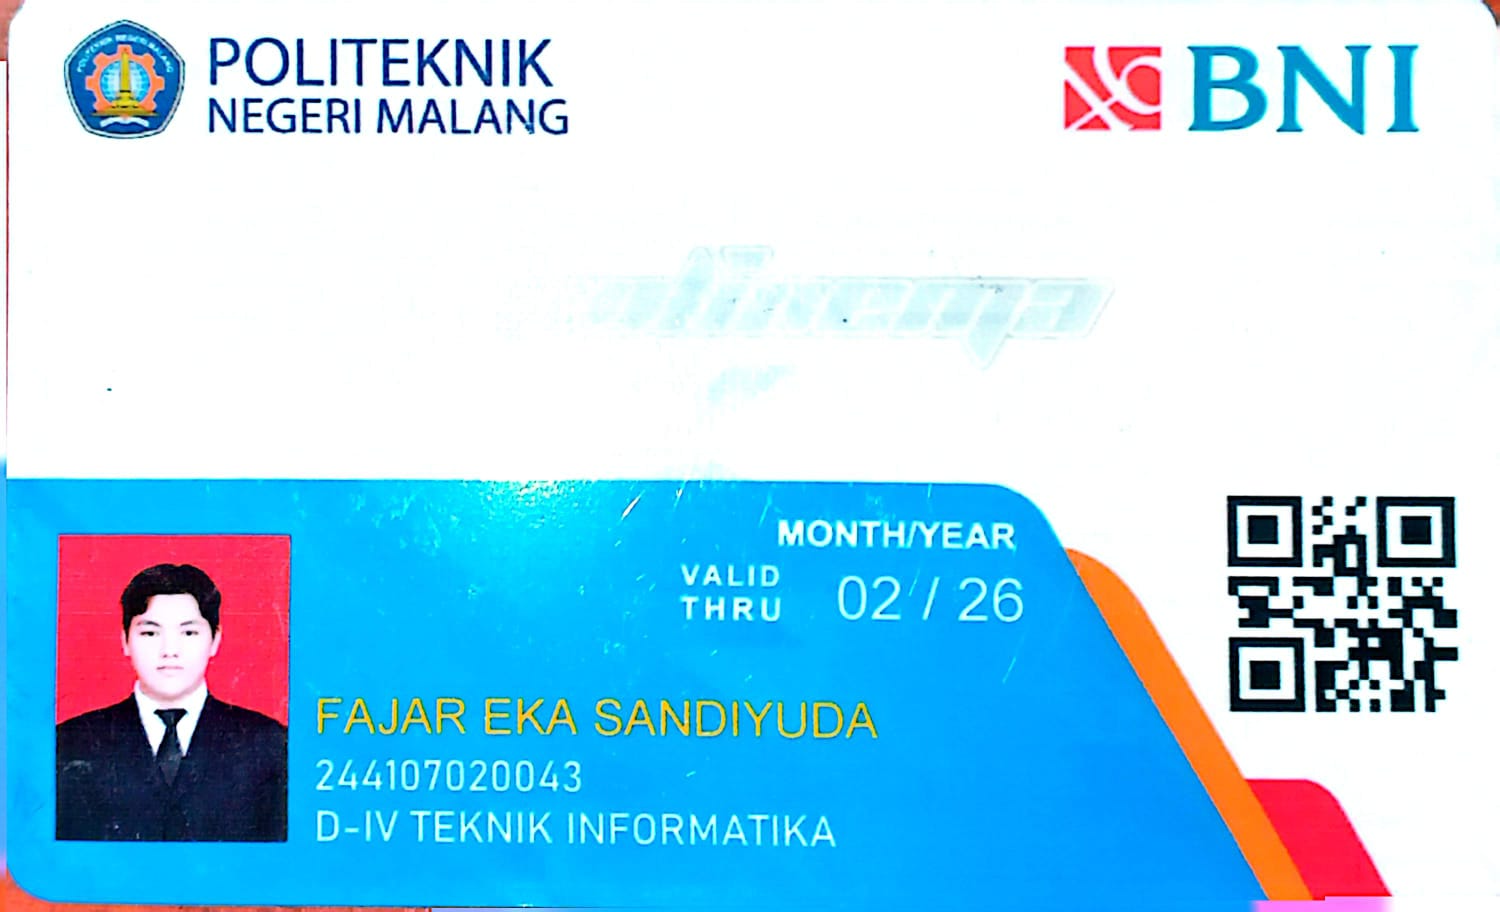

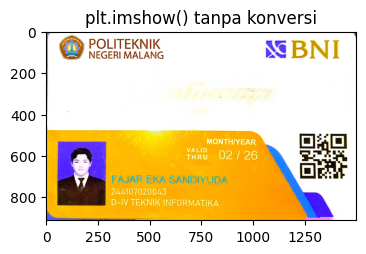

Nilai piksel di (10,10) dari array yang sama (urutan BGR): [107 119 197]
-> Piksel yang diberikan ke cv2_imshow() dan plt.imshow() adalah array yang sama persis;
   perbedaan tampilan murni berasal dari asumsi urutan kanal masing-masing fungsi, bukan dari nilai datanya.


In [ ]:
if FILE_UTAMA:
    img_q1 = cv.imread(FILE_UTAMA)

    print("cv2_imshow (BGR apa adanya):")
    cv2_imshow(img_q1)

    plt.figure(figsize=(4, 3))
    plt.imshow(img_q1)  # tanpa konversi
    plt.title("plt.imshow() tanpa konversi")
    plt.show()

    y, x = 10, 10
    print(f"Nilai piksel di ({y},{x}) dari array yang sama (urutan BGR): {img_q1[y, x]}")
    print("-> Piksel yang diberikan ke cv2_imshow() dan plt.imshow() adalah array yang sama persis;")
    print("   perbedaan tampilan murni berasal dari asumsi urutan kanal masing-masing fungsi, bukan dari nilai datanya.")
else:
    print("Lewati: belum ada citra yang diupload.")

### Pertanyaan 2
Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan `dtype`, `min()`, `max()`, dan `nbytes` keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

**Jawaban:**
Secara visual kedua kanvas identik karena semua nilainya 0 (hitam), jadi tampilannya sama. Namun `nbytes` berbeda: int32 menggunakan 4 byte per elemen sedangkan int16 hanya 2 byte per elemen, sehingga kanvas int32 berukuran memori dua kali lipat dari int16 meskipun bentuk (shape) dan isinya sama. Ini karena `dtype` menentukan berapa byte yang dialokasikan untuk menyimpan setiap nilai piksel, bukan berapa banyak piksel yang ada.

In [ ]:
tinggi, lebar = 200, 200
kanvas_16 = np.zeros((tinggi, lebar, 3), dtype=np.int16)
kanvas_32 = np.zeros((tinggi, lebar, 3), dtype=np.int32)

print(f"{'':12}{'int16':>12}{'int32':>12}")
print(f"{'dtype':12}{str(kanvas_16.dtype):>12}{str(kanvas_32.dtype):>12}")
print(f"{'min()':12}{kanvas_16.min():>12}{kanvas_32.min():>12}")
print(f"{'max()':12}{kanvas_16.max():>12}{kanvas_32.max():>12}")
print(f"{'nbytes':12}{kanvas_16.nbytes:>12}{kanvas_32.nbytes:>12}")
print(f"\nRasio nbytes (int32 / int16): {kanvas_32.nbytes / kanvas_16.nbytes}")

                   int16       int32
dtype              int16       int32
min()                  0           0
max()                  0           0
nbytes            240000      480000

Rasio nbytes (int32 / int16): 2.0


### Pertanyaan 3
Apa kegunaan baris `from google.colab.patches import cv2_imshow`, dan mengapa `cv.imshow()` bawaan OpenCV tidak dapat dipakai di Google Colab?

**Jawaban:**
`cv.imshow()` bawaan OpenCV membuka jendela GUI pada sistem operasi lokal untuk menampilkan gambar. Google Colab berjalan di server cloud tanpa antarmuka GUI/display, sehingga pemanggilan `cv.imshow()` akan gagal atau menyebabkan crash pada kernel. Baris `from google.colab.patches import cv2_imshow` mengimpor fungsi pengganti yang dibuat khusus oleh tim Google Colab: alih-alih membuka jendela, fungsi ini merender gambar sebagai keluaran (output) sel notebook, sehingga bisa dipakai di lingkungan cloud tanpa GUI.

Demonstrasi: cv2_imshow() bekerja di Colab tanpa GUI.


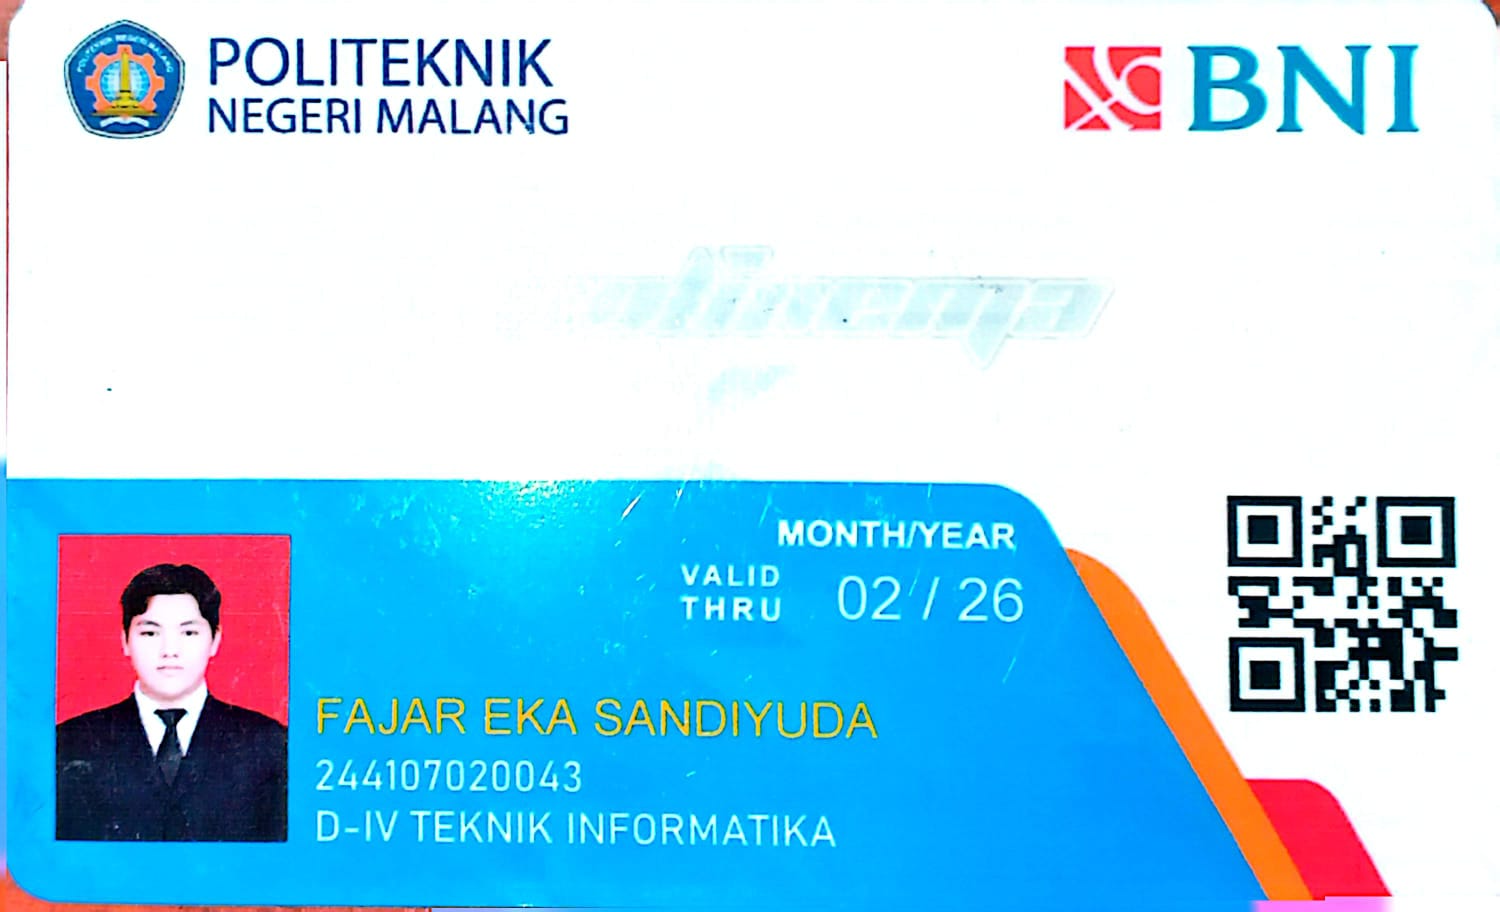

Berhasil ditampilkan sebagai output sel, bukan jendela terpisah.


In [ ]:
print("Demonstrasi: cv2_imshow() bekerja di Colab tanpa GUI.")
if FILE_UTAMA:
    contoh = cv.imread(FILE_UTAMA)
    cv2_imshow(contoh)
    print("Berhasil ditampilkan sebagai output sel, bukan jendela terpisah.")
else:
    print("Lewati demo visual: belum ada citra yang diupload.")

### Pertanyaan 4
Citra yang dibaca dengan `skimage.io.imread()` ditampilkan berdampingan dengan hasil `cv.cvtColor(img, cv.COLOR_BGR2RGB)` atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.

**Jawaban:**
`skimage.io.imread()` langsung membaca citra dalam urutan RGB, sehingga saat ditampilkan dengan `plt.imshow()` warnanya benar. `cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)` pada citra yang dibaca `cv.imread()` (BGR) juga menghasilkan urutan RGB yang benar setelah konversi. Karena keduanya sama-sama menghasilkan array RGB yang benar, nilai pikselnya seharusnya identik (dalam batas kompresi/decoding). Jika salah satunya *belum* dikonversi (misalnya array BGR ditampilkan langsung tanpa `cvtColor`), maka kanal merah dan birunya akan tertukar — ini bisa dibuktikan dengan membandingkan nilai kanal R dan B pada piksel yang sama.

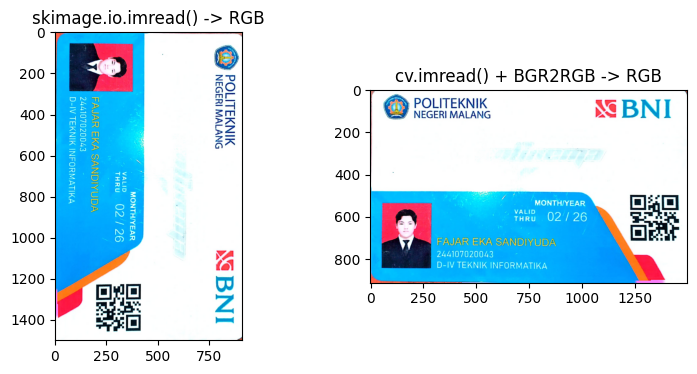

Piksel skimage (RGB asli)      : [250  99  68]
Piksel cv2 setelah BGR2RGB     : [218 201 207]
Piksel cv2 SEBELUM konversi(BGR): [207 201 218]

-> Bandingkan urutan R dan B pada baris terakhir dengan dua baris di atasnya:
   nilai BGR mentah punya kanal R dan B tertukar dibanding versi RGB yang sudah benar.


In [ ]:
if FILE_UTAMA:
    img_bgr_q4 = cv.imread(FILE_UTAMA)
    img_skimage = skio.imread(FILE_UTAMA)          # hasil: RGB
    img_cv2_converted = cv.cvtColor(img_bgr_q4, cv.COLOR_BGR2RGB)  # hasil: RGB

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img_skimage)
    axes[0].set_title("skimage.io.imread() -> RGB")
    axes[1].imshow(img_cv2_converted)
    axes[1].set_title("cv.imread() + BGR2RGB -> RGB")
    plt.show()

    y, x = 15, 15
    print("Piksel skimage (RGB asli)      :", img_skimage[y, x])
    print("Piksel cv2 setelah BGR2RGB     :", img_cv2_converted[y, x])
    print("Piksel cv2 SEBELUM konversi(BGR):", img_bgr_q4[y, x])
    print()
    print("-> Bandingkan urutan R dan B pada baris terakhir dengan dua baris di atasnya:")
    print("   nilai BGR mentah punya kanal R dan B tertukar dibanding versi RGB yang sudah benar.")
else:
    print("Lewati: belum ada citra yang diupload.")

### Pertanyaan 5
Setelah citra ditampilkan dengan `figsize` yang jauh lebih besar, apakah nilai `img.shape` ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.

**Jawaban:**
Tidak. `figsize` pada `plt.figure()` hanya mengatur ukuran kanvas/area gambar dalam satuan inci saat *ditampilkan* di layar — ini murni properti visual dari plot Matplotlib. Nilai `img.shape` (jumlah piksel sebenarnya dalam array NumPy) sama sekali tidak berubah, karena tidak ada piksel yang ditambah atau dikurangi. Hanya fungsi yang benar-benar memanipulasi array datanya, seperti `cv.resize()`, yang mengubah `img.shape`.

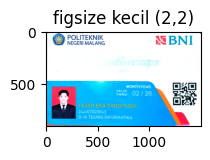

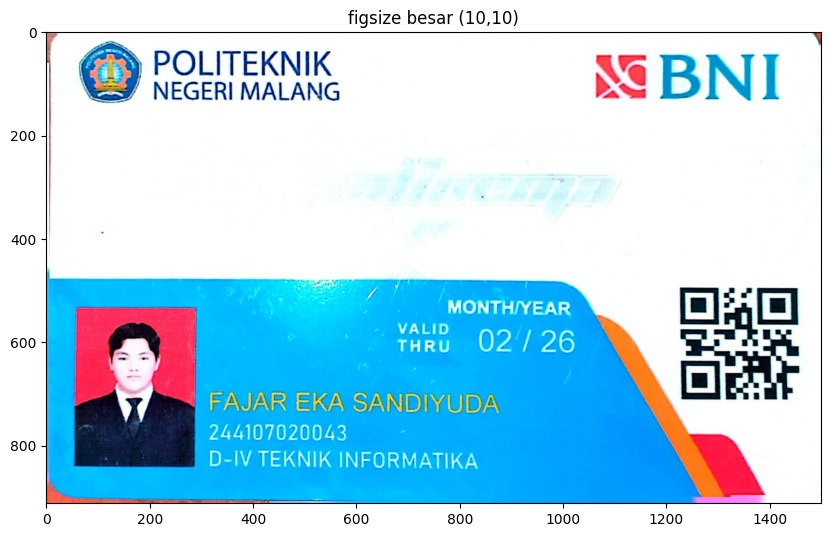

shape sebelum menampilkan dengan figsize besar: (912, 1500, 3)
shape sesudah menampilkan dengan figsize besar : (912, 1500, 3)
Apakah berubah? False


In [ ]:
if FILE_UTAMA:
    img_q5 = cv.imread(FILE_UTAMA)
    shape_sebelum = img_q5.shape

    plt.figure(figsize=(2, 2))
    plt.imshow(cv.cvtColor(img_q5, cv.COLOR_BGR2RGB))
    plt.title("figsize kecil (2,2)")
    plt.show()

    plt.figure(figsize=(10, 10))
    plt.imshow(cv.cvtColor(img_q5, cv.COLOR_BGR2RGB))
    plt.title("figsize besar (10,10)")
    plt.show()

    shape_sesudah = img_q5.shape
    print("shape sebelum menampilkan dengan figsize besar:", shape_sebelum)
    print("shape sesudah menampilkan dengan figsize besar :", shape_sesudah)
    print("Apakah berubah?", shape_sebelum != shape_sesudah)
else:
    print("Lewati: belum ada citra yang diupload.")

## 3. TUGAS PRAKTIKUM — Penerapan
Berdasarkan praktikum bagian 1 dan 2.

### Tugas 1
Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.

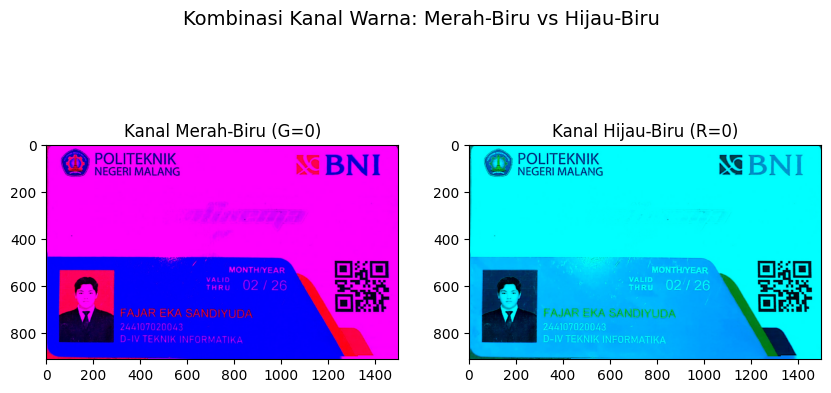

In [ ]:
if FILE_UTAMA:
    img_t1 = cv.imread(FILE_UTAMA)
    img_t1_rgb = cv.cvtColor(img_t1, cv.COLOR_BGR2RGB)

    # Kanal Merah-Biru: hijau (indeks 1) dinolkan
    img_rb = img_t1_rgb.copy()
    img_rb[:, :, 1] = 0

    # Kanal Hijau-Biru: merah (indeks 0) dinolkan
    img_gb = img_t1_rgb.copy()
    img_gb[:, :, 0] = 0

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle("Kombinasi Kanal Warna: Merah-Biru vs Hijau-Biru", fontsize=14)
    axes[0].imshow(img_rb)
    axes[0].set_title("Kanal Merah-Biru (G=0)")
    axes[1].imshow(img_gb)
    axes[1].set_title("Kanal Hijau-Biru (R=0)")
    plt.show()
else:
    print("Lewati: belum ada citra yang diupload.")

### Tugas 2
Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.

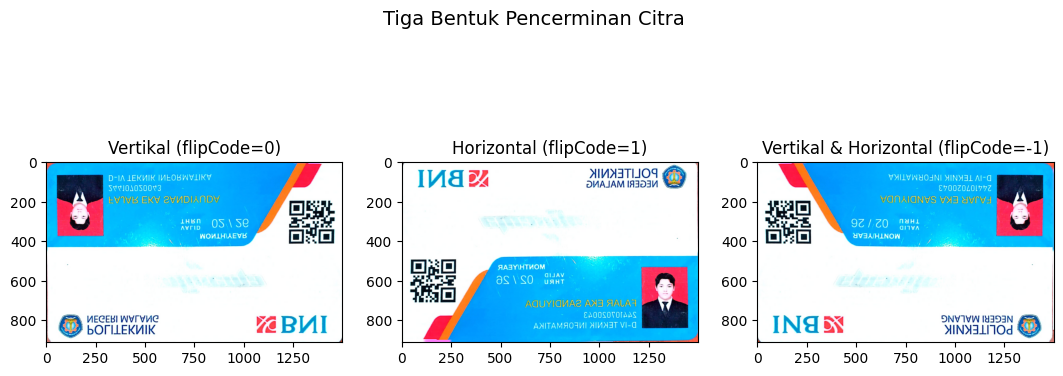

In [ ]:
if FILE_UTAMA:
    img_t2 = cv.imread(FILE_UTAMA)

    flip_vert = cv.flip(img_t2, 0)
    flip_horiz = cv.flip(img_t2, 1)
    flip_both = cv.flip(img_t2, -1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    fig.suptitle("Tiga Bentuk Pencerminan Citra", fontsize=14)
    for ax, im, label in zip(
        axes,
        [flip_vert, flip_horiz, flip_both],
        ["Vertikal (flipCode=0)", "Horizontal (flipCode=1)", "Vertikal & Horizontal (flipCode=-1)"]
    ):
        ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
        ax.set_title(label)
    plt.show()
else:
    print("Lewati: belum ada citra yang diupload.")

### Tugas 3
Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah/badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

> Menggunakan `FILE_AKTIVITAS`. Koordinat dibuat proporsional terhadap ukuran citra agar tetap wajar pada foto ukuran berapa pun — silakan sesuaikan posisi persis sesuai lokasi wajah/badan pada foto Anda.

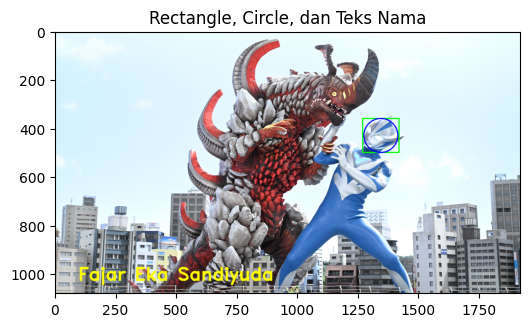

In [ ]:
NAMA_ANDA = "Fajar Eka Sandiyuda"

if FILE_AKTIVITAS:
    img_t3 = cv.imread(FILE_AKTIVITAS)
    h, w = img_t3.shape[:2]
    img_t3_draw = img_t3.copy()

    cv.rectangle(img_t3_draw, (1270,500), (1420,360), (0,255,0), thickness=4)
    cv.circle(img_t3_draw, (1345,430), 70, (255,0,0), thickness=4)

    org = (int(w * 0.05), int(h * 0.95))
    fontScale = max(0.6, w / 800)
    cv.putText(img_t3_draw, NAMA_ANDA, org, cv.FONT_HERSHEY_DUPLEX,
                fontScale, (0, 255, 255), thickness=max(1, w // 300), lineType=cv.LINE_AA)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv.cvtColor(img_t3_draw, cv.COLOR_BGR2RGB))
    plt.title("Rectangle, Circle, dan Teks Nama")
    plt.show()
else:
    print("Lewati: upload foto aktivitas Anda terlebih dahulu (FILE_AKTIVITAS).")

## 4. TUGAS PRAKTIKUM — Analisa
Rumuskan satu pertanyaan tentang citra digital yang dapat dijawab menggunakan kode dari modul ini.

**Pertanyaan yang dipilih:** Berapa persen piksel pada foto KTM yang lebih gelap dari nilai intensitas 100 (pada citra grayscale)?

**Rancangan program:**
1. Baca foto KTM, konversi ke grayscale.
2. Hitung jumlah piksel dengan nilai < 100.
3. Bagi dengan total piksel, kalikan 100% untuk mendapatkan persentase.

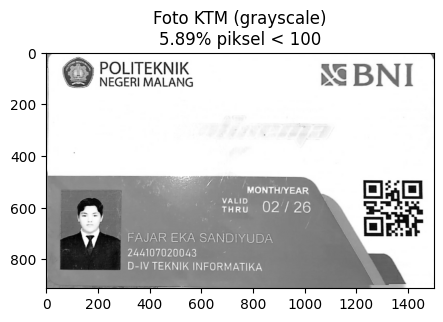

Total piksel        : 1368000
Piksel lebih gelap dari 100: 80571
Persentase           : 5.89%


In [ ]:
if FILE_KTM:
    img_ktm = cv.imread(FILE_KTM)
    gray_ktm = cv.cvtColor(img_ktm, cv.COLOR_BGR2GRAY)

    ambang = 100
    total_piksel = gray_ktm.size
    piksel_gelap = np.sum(gray_ktm < ambang)
    persentase = (piksel_gelap / total_piksel) * 100

    plt.figure(figsize=(5, 4))
    plt.imshow(gray_ktm, cmap='gray')
    plt.title(f"Foto KTM (grayscale)\n{persentase:.2f}% piksel < {ambang}")
    plt.show()

    print(f"Total piksel        : {total_piksel}")
    print(f"Piksel lebih gelap dari {ambang}: {piksel_gelap}")
    print(f"Persentase           : {persentase:.2f}%")
else:
    print("Lewati: upload foto KTM terlebih dahulu (FILE_KTM).")

**Data hasil:** (lihat keluaran program di atas — persentase piksel gelap ditampilkan otomatis setelah citra KTM diupload dan sel dijalankan.)

**Kesimpulan:** Persentase piksel gelap memberi indikasi kasar tentang seberapa gelap/terang keseluruhan foto KTM (dipengaruhi pencahayaan saat pengambilan foto dan latar belakang gambar). Nilai persentase yang tinggi menandakan foto didominasi area gelap (misal latar belakang gelap atau foto kurang cahaya), sedangkan nilai yang rendah menandakan foto didominasi area terang.

## 5. TUGAS PRAKTIKUM — Aplikasi
Hanya menggunakan fungsi yang dipelajari pada modul ini (pembacaan berkas, pengirisan, `cv.resize`, `cv.flip`, `cv.cvtColor`, fungsi penggambaran OpenCV, pembuatan kanvas NumPy). Semua ukuran/posisi/ketebalan dihitung **adaptif** dari ukuran citra masukan.

### Studi Kasus 1 — Label Identitas Adaptif pada Foto Dokumentasi
Panitia perlu membubuhkan label identitas pada foto dengan berbagai ukuran, sehingga label harus terlihat seimbang tanpa disetel manual satu per satu. Tinggi bar dan ukuran huruf dihitung proporsional terhadap ukuran citra masukan.

potrait.jpg: ukuran asli (1200, 696) -> tinggi bar 120 px


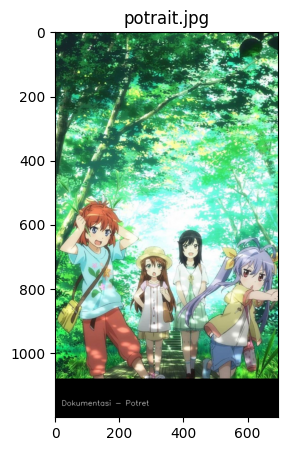

landscape.jpg: ukuran asli (414, 736) -> tinggi bar 41 px


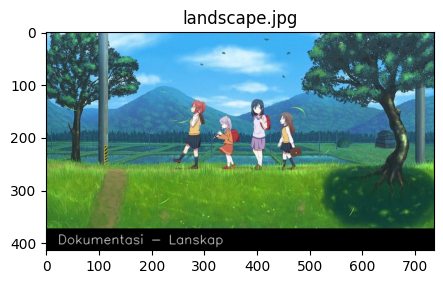

In [ ]:
def tambah_label_adaptif(img, teks, warna_bar=(0, 0, 0), warna_teks=(255, 255, 255)):
    """Menambahkan bar label identitas di bagian bawah citra.
    Tinggi bar, ukuran font, dan ketebalan dihitung proporsional dari ukuran citra masukan."""
    h, w = img.shape[:2]
    hasil = img.copy()

    tinggi_bar = max(20, int(h * 0.10))          # 10% dari tinggi citra
    fontScale = max(0.4, w / 900)                # menyesuaikan lebar citra
    ketebalan = max(1, w // 400)

    hasil[h - tinggi_bar:h, 0:w] = warna_bar

    org = (int(w * 0.03), h - int(tinggi_bar * 0.30))
    cv.putText(hasil, teks, org, cv.FONT_HERSHEY_SIMPLEX,
                fontScale, warna_teks, thickness=ketebalan, lineType=cv.LINE_AA)
    return hasil

# Uji fungsi pada dua citra berbeda ukuran (potret dan lanskap) agar proporsinya terlihat konsisten
for nama_file, label in [(FILE_POTRET, "Dokumentasi - Potret"), (FILE_LANSKAP, "Dokumentasi - Lanskap")]:
    if nama_file:
        gambar = cv.imread(nama_file)
        hasil = tambah_label_adaptif(gambar, label)
        print(f"{nama_file}: ukuran asli {gambar.shape[:2]} -> tinggi bar {int(gambar.shape[0]*0.10)} px")
        plt.figure(figsize=(5, 5))
        plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
        plt.title(f"{nama_file}")
        plt.show()
    else:
        print(f"Lewati: '{label}' membutuhkan file yang belum diupload.")

### Studi Kasus 2 — Thumbnail Persegi 1:1 (seperti Marketplace)
Foto berukuran potret/lanskap apa pun diubah menjadi thumbnail persegi tanpa mengubah rasio aslinya: citra diperkecil agar pas di dalam kanvas persegi, ditempatkan tepat di tengah, sisa ruang diisi kanvas berwarna, dan ditambahkan "logo" nama toko berukuran proporsional.

potrait.jpg: ukuran asli (1200, 696) -> thumbnail (500, 500)


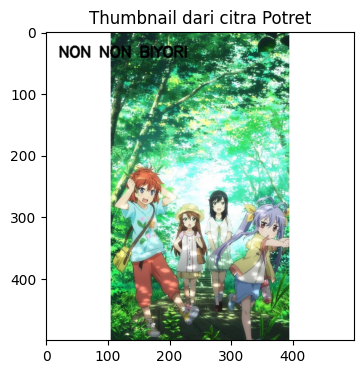

landscape.jpg: ukuran asli (414, 736) -> thumbnail (500, 500)


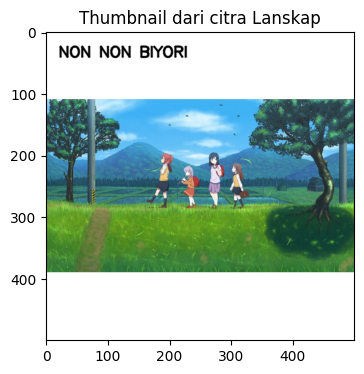

In [ ]:
def buat_thumbnail_persegi(img, ukuran=400, warna_kanvas=(255, 255, 255), nama_toko="NON NON BIYORI"):
    """Mengubah citra ukuran berapa pun menjadi thumbnail persegi (ukuran x ukuran)
    tanpa mengubah rasio aslinya. Sisa ruang diisi warna kanvas, citra diposisikan di tengah,
    dan logo nama toko ditambahkan dengan ukuran proporsional."""
    h, w = img.shape[:2]

    # Hitung skala terbesar yang membuat citra tetap muat di dalam kanvas ukuran x ukuran
    skala = min(ukuran / w, ukuran / h)
    w_baru, h_baru = int(w * skala), int(h * skala)
    img_resized = cv.resize(img, (w_baru, h_baru))

    # Kanvas persegi
    kanvas = np.full((ukuran, ukuran, 3), warna_kanvas, dtype=np.uint8)

    # Posisi tengah menggunakan pengirisan (slicing)
    y_off = (ukuran - h_baru) // 2
    x_off = (ukuran - w_baru) // 2
    kanvas[y_off:y_off + h_baru, x_off:x_off + w_baru] = img_resized

    # Logo nama toko: ukuran font & posisi proporsional terhadap ukuran kanvas
    fontScale = max(0.8, ukuran / 900)
    ketebalan = max(2, ukuran // 400)
    org = (int(ukuran * 0.04), int(ukuran * 0.08))
    cv.putText(kanvas, nama_toko, org, cv.FONT_HERSHEY_SIMPLEX,
                fontScale, (0, 0, 0), thickness=ketebalan, lineType=cv.LINE_AA)

    return kanvas

for nama_file, judul in [(FILE_POTRET, "Thumbnail dari citra Potret"), (FILE_LANSKAP, "Thumbnail dari citra Lanskap")]:
    if nama_file:
        gambar = cv.imread(nama_file)
        thumb = buat_thumbnail_persegi(gambar, ukuran=500, nama_toko="NON NON BIYORI")
        print(f"{nama_file}: ukuran asli {gambar.shape[:2]} -> thumbnail {thumb.shape[:2]}")
        plt.figure(figsize=(4, 4))
        plt.imshow(cv.cvtColor(thumb, cv.COLOR_BGR2RGB))
        plt.title(judul)
        plt.show()
    else:
        print(f"Lewati: '{judul}' membutuhkan file yang belum diupload.")